# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques




<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [ ]:
#Importation de la librairie Pandas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [ ]:
#Importation du fichier transaction.csv
transactions = pd.read_csv('/content/Transactions.csv',sep=None, engine='python')

#Importation du fichier customers.csv
customers = pd.read_csv('/content/customers.csv',sep=None, engine='python')

#Importation du fichier products.csv
products = pd.read_csv('/content/products.csv',sep=None, engine='python')


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier transactions</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
transactions.info()
print("Le tableau comporte {} observation(s) ou article(s)".format(transactions.shape[0]))
print("Le tableau comporte {} colonne(s)".format(transactions.shape[1]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ﻿id_prod    687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB
Le tableau comporte 1048575 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [ ]:
#suppression des NAN
transactions = transactions.dropna()
transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ﻿id_prod    687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 26.2+ MB


In [ ]:
#Affichage les 5 premières lignes de la table transactions
transactions.head(5)

,﻿id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


In [ ]:
#verification des noms des colonnes
print(transactions.columns)

Index(['﻿id_prod', 'date', 'session_id', 'client_id'], dtype='object')


In [ ]:
#modification du nom de la colonne id_prod dans la table transaction
transactions = transactions.rename(columns={'﻿id_prod': 'id_prod'})

In [ ]:
#verifier l'unicité des données session_id dans transactions
transactions_doublons = transactions[transactions.duplicated(keep=False)]
print(transactions_doublons)

Empty DataFrame
Columns: [id_prod, date, session_id, client_id]
Index: []


In [ ]:
doublon_transactions_false=transactions.duplicated(keep=False)
print(doublon_transactions_false)

0         False
1         False
2         False
3         False
4         False
          ...  
687529    False
687530    False
687531    False
687532    False
687533    False
Length: 687534, dtype: bool


In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 26.2+ MB


<div style="border: 1px solid RGB(51,165,182);" >
 <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier customers</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
customers.info()
print("Le tableau comporte {} observation(s) ou article(s)".format(customers.shape[0]))
print("Le tableau comporte {} colonne(s)".format(customers.shape[1]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ﻿client_id  8621 non-null   object
 1   sex         8621 non-null   object
 2   birth       8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB
Le tableau comporte 8621 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
#suppression des NAN
customers = customers.dropna()
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ﻿client_id  8621 non-null   object
 1   sex         8621 non-null   object
 2   birth       8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [ ]:
#Affichage les 5 premières lignes de la table transactions
customers.head(5)

,﻿client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [ ]:
#verifier le nom des colonnes de customers
print(customers.columns)

Index(['﻿client_id', 'sex', 'birth'], dtype='object')


In [ ]:
#modification du nom de la colonne client_id
customers = customers.rename(columns={'﻿client_id': 'client_id'})

In [ ]:
#verifier l'unicité des données id_prod dans customers
doublon_customers= customers['client_id'].is_unique
print(doublon_customers)

True


### 2.3 - Analyse exploratoire du fichier products

In [ ]:
#Afficher les dimensions du dataset
products.info()
print("Le tableau comporte {} observation(s) ou article(s)".format(products.shape[0]))
print("Le tableau comporte {} colonne(s)".format(products.shape[1]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ﻿id_prod  3286 non-null   object 
 1   price     3286 non-null   float64
 2   categ     3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB
Le tableau comporte 3286 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
#suppression des NAN
products = products.dropna()

In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ﻿id_prod  3286 non-null   object 
 1   price     3286 non-null   float64
 2   categ     3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [ ]:
#verifier le nom des colonnes de products
print(products.columns)

Index(['﻿id_prod', 'price', 'categ'], dtype='object')


In [ ]:
#modification de la colonne id_prod
products = products.rename(columns={'﻿id_prod': 'id_prod'})

In [ ]:
#verifier l'unicité des données id_prod dans products
doublon_products= products['id_prod'].is_unique
print(doublon_products)

True


In [ ]:
#verifier si prix négatif dans products
prix_negatifs = products[products["price"]<0]
print(prix_negatifs)

Empty DataFrame
Columns: [id_prod, price, categ]
Index: []


### 2.4 Modification des colonnes en date pour l'analyse des données transactions

In [ ]:
#création des colonnes de date
transactions['date'] = pd.to_datetime(transactions['date']).dt.date
transactions['jour'] = pd.to_datetime(transactions['date']).dt.day.astype(int)
transactions['mois'] = pd.to_datetime(transactions['date']).dt.month.astype(int)
transactions['annee'] = pd.to_datetime(transactions['date']).dt.year.astype(int)

In [ ]:
#création transaction année-mois
transactions['année_mois'] = transactions['annee'].astype(str) + '_' + transactions['mois'].astype(str)
print(transactions)

       id_prod        date session_id client_id  jour  mois  annee année_mois
0       0_1259  2021-03-01        s_1     c_329     1     3   2021     2021_3
1       0_1390  2021-03-01        s_2     c_664     1     3   2021     2021_3
2       0_1352  2021-03-01        s_3     c_580     1     3   2021     2021_3
3       0_1458  2021-03-01        s_4    c_7912     1     3   2021     2021_3
4       0_1358  2021-03-01        s_5    c_2033     1     3   2021     2021_3
...        ...         ...        ...       ...   ...   ...    ...        ...
687529   1_508  2023-02-28   s_348444    c_3573    28     2   2023     2023_2
687530    2_37  2023-02-28   s_348445      c_50    28     2   2023     2023_2
687531   1_695  2023-02-28   s_348446     c_488    28     2   2023     2023_2
687532  0_1547  2023-02-28   s_348447    c_4848    28     2   2023     2023_2
687533  0_1398  2023-02-28   s_348435    c_3575    28     2   2023     2023_2

[687534 rows x 8 columns]


In [ ]:
products.columns

Index(['id_prod', 'price', 'categ'], dtype='object')

### 2.5 création de la jointure et le dataframe CA

In [ ]:
#Création de la jointure entre les données
CA = pd.merge(transactions,products,on='id_prod')
print(CA)

       id_prod        date session_id client_id  jour  mois  annee année_mois  \
0       0_1259  2021-03-01        s_1     c_329     1     3   2021     2021_3   
1       0_1390  2021-03-01        s_2     c_664     1     3   2021     2021_3   
2       0_1352  2021-03-01        s_3     c_580     1     3   2021     2021_3   
3       0_1458  2021-03-01        s_4    c_7912     1     3   2021     2021_3   
4       0_1358  2021-03-01        s_5    c_2033     1     3   2021     2021_3   
...        ...         ...        ...       ...   ...   ...    ...        ...   
687529   1_508  2023-02-28   s_348444    c_3573    28     2   2023     2023_2   
687530    2_37  2023-02-28   s_348445      c_50    28     2   2023     2023_2   
687531   1_695  2023-02-28   s_348446     c_488    28     2   2023     2023_2   
687532  0_1547  2023-02-28   s_348447    c_4848    28     2   2023     2023_2   
687533  0_1398  2023-02-28   s_348435    c_3575    28     2   2023     2023_2   

        price  categ  
0   

# 3 Analyse des indicateurs liés au chiffre d'affaire

In [ ]:
#calcul du chiffre d'affaires
chiffre_affaires = CA['price'].sum()
print(chiffre_affaires)

12027663.100000003


In [ ]:
CA_par_date = CA.groupby('année_mois').agg({'price': 'sum'}).reset_index()
print(CA_par_date)

   année_mois      price
0     2021_10  494733.16
1     2021_11  516167.73
2     2021_12  525917.28
3      2021_3  482440.61
4      2021_4  476109.30
5      2021_5  492943.47
6      2021_6  484088.56
7      2021_7  482835.40
8      2021_8  482284.79
9      2021_9  507240.68
10     2022_1  525338.99
11    2022_10  507917.77
12    2022_11  496664.94
13    2022_12  510219.50
14     2022_2  535571.50
15     2022_3  515456.53
16     2022_4  492998.94
17     2022_5  517132.60
18     2022_6  496016.12
19     2022_7  510783.12
20     2022_8  506467.27
21     2022_9  494114.53
22     2023_1  517540.55
23     2023_2  456679.76


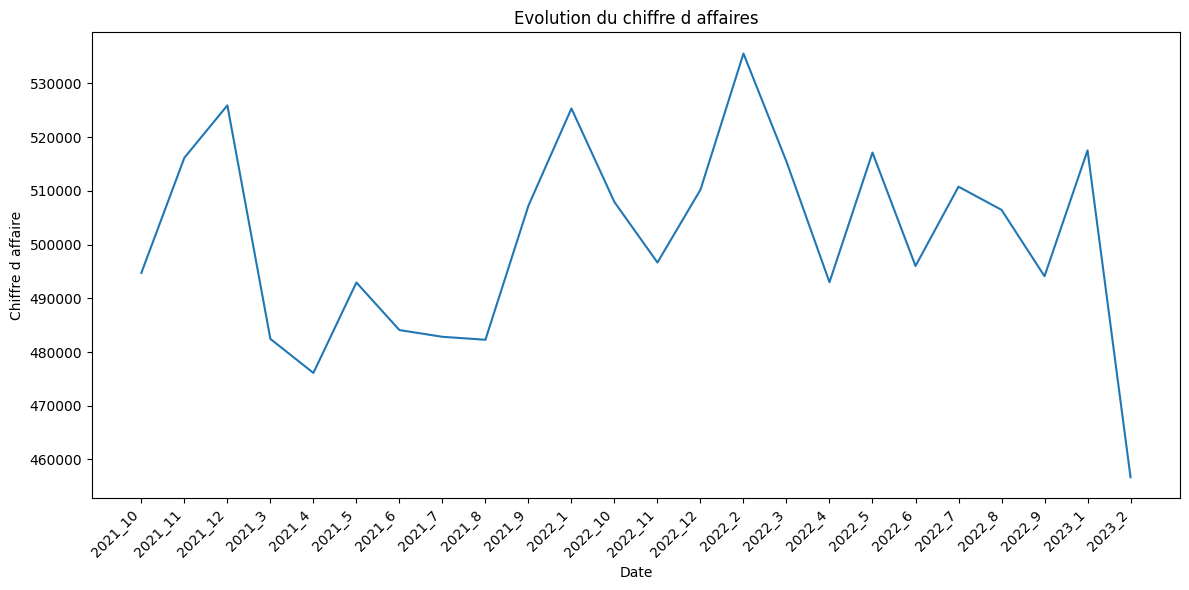

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(CA_par_date['année_mois'], CA_par_date['price'])
plt.xlabel('Date')
plt.ylabel('Chiffre d affaire')
plt.title('Evolution du chiffre d affaires')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
ts = pd.Series(CA_par_date['price'].values, index=CA_par_date['année_mois'])

In [ ]:
#la taille de la fenêtre pour la moyenne mobile en mois
window_size = 3
chiffre_affaires_moyenne_mobile_par_année_mois = ts.rolling(window=window_size).mean()
print(chiffre_affaires_moyenne_mobile_par_année_mois.head(30))


année_mois
2021_10              NaN
2021_11              NaN
2021_12    512272.723333
2021_3     508175.206667
2021_4     494822.396667
2021_5     483831.126667
2021_6     484380.443333
2021_7     486622.476667
2021_8     483069.583333
2021_9     490786.956667
2022_1     504954.820000
2022_10    513499.146667
2022_11    509973.900000
2022_12    504934.070000
2022_2     514151.980000
2022_3     520415.843333
2022_4     514675.656667
2022_5     508529.356667
2022_6     502049.220000
2022_7     507977.280000
2022_8     504422.170000
2022_9     503788.306667
2023_1     506040.783333
2023_2     489444.946667
dtype: float64


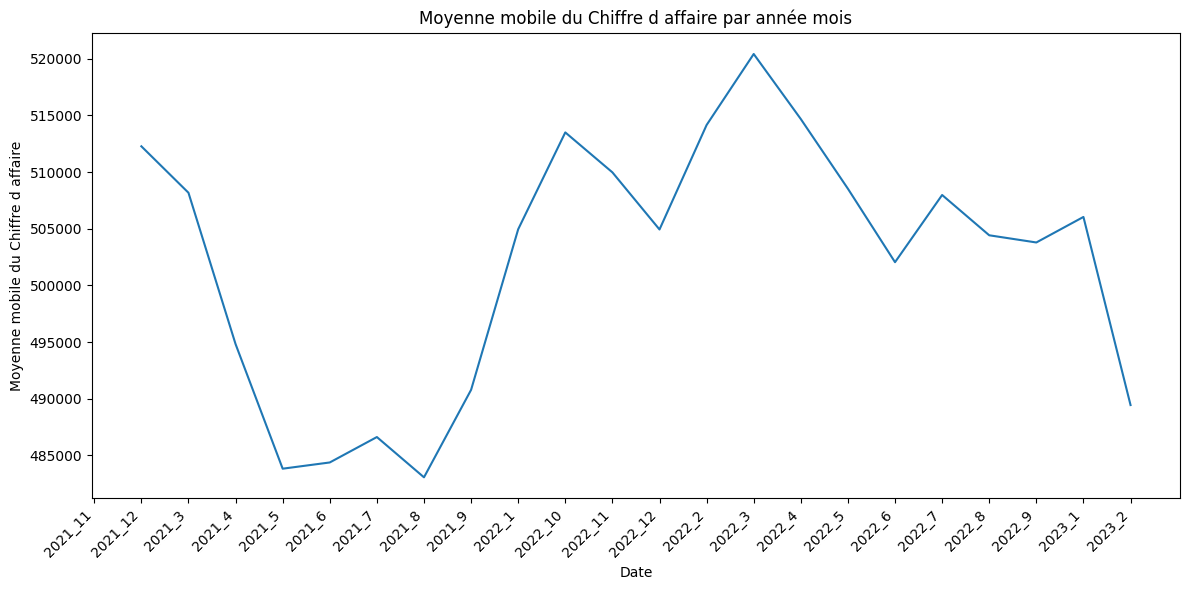

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(chiffre_affaires_moyenne_mobile_par_année_mois.index, chiffre_affaires_moyenne_mobile_par_année_mois.values)
plt.xlabel('Date')
plt.ylabel('Moyenne mobile du Chiffre d affaire')
plt.title('Moyenne mobile du Chiffre d affaire par année mois')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#calcul du chiffre d'affaires par catégorie
chiffre_affaires_categorie=CA.groupby('categ')['price'].sum()
print(chiffre_affaires_categorie)

categ
0    4419730.97
1    4827657.11
2    2780275.02
Name: price, dtype: float64


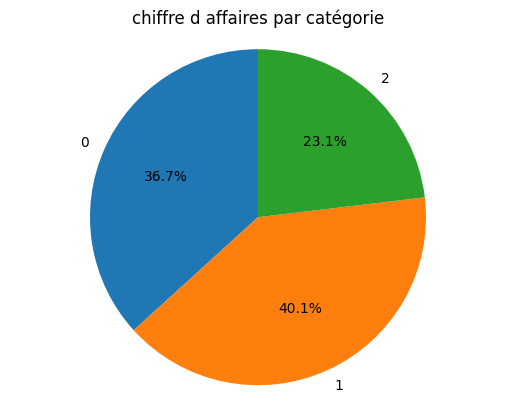

In [ ]:
import matplotlib.pyplot as plt
# chiffre d'affaire en diagramme circulaire
plt.pie(chiffre_affaires_categorie,labels=chiffre_affaires_categorie.index,autopct='%1.1f%%', startangle=90)
plt.title('chiffre d affaires par catégorie')
plt.axis('equal')
plt.show()

année_mois
2021_10    6190
2021_11    5875
2021_12    5867
2021_3     5676
2021_4     5674
2021_5     5644
2021_6     5659
2021_7     5672
2021_8     5642
2021_9     5693
2022_1     5809
2022_10    5755
2022_11    5749
2022_12    5765
2022_2     5729
2022_3     5835
2022_4     5695
2022_5     5843
2022_6     5717
2022_7     5778
2022_8     5805
2022_9     5738
2023_1     5828
2023_2     5587
Name: client_id, dtype: int64


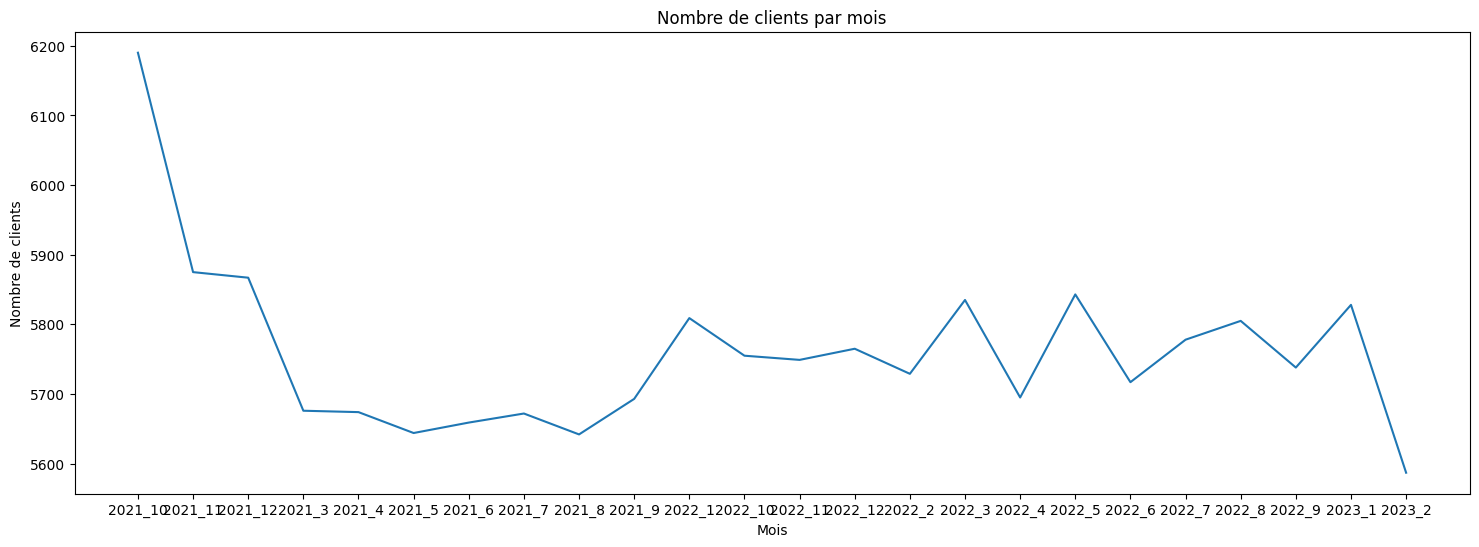

In [ ]:
#calcul du nombre de client par mois
nombre_client_par_mois = CA.groupby('année_mois')['client_id'].nunique()
print(nombre_client_par_mois)
# courbe du nombre de client par mois
plt.figure(figsize=(18, 6))
plt.plot(nombre_client_par_mois.index, nombre_client_par_mois.values)
plt.xlabel('Mois')
plt.ylabel('Nombre de clients')
plt.title('Nombre de clients par mois')
plt.show()

In [ ]:
#nombre de transactions par mois
nombre_transactions_mois=CA.groupby('année_mois')['session_id'].count()
print(nombre_transactions_mois)

année_mois
2021_10    30022
2021_11    28311
2021_12    32457
2021_3     28601
2021_4     28443
2021_5     28285
2021_6     26850
2021_7     24738
2021_8     25650
2021_9     33314
2022_1     29343
2022_10    28964
2022_11    28563
2022_12    28619
2022_2     29594
2022_3     29696
2022_4     27602
2022_5     29975
2022_6     28504
2022_7     28670
2022_8     28544
2022_9     28306
2023_1     28938
2023_2     25545
Name: session_id, dtype: int64


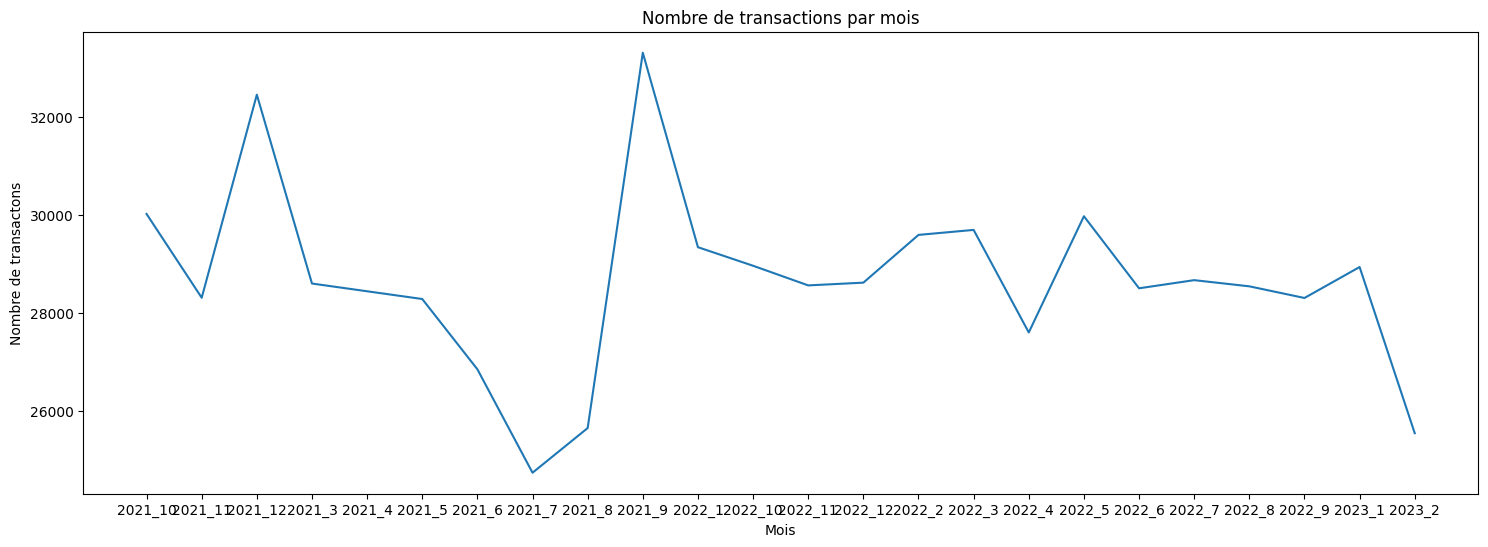

In [ ]:
# courbe du nombre de transaction par mois
plt.figure(figsize=(18, 6))
plt.plot(nombre_transactions_mois.index, nombre_transactions_mois.values)
plt.xlabel('Mois')
plt.ylabel('Nombre de transactons')
plt.title('Nombre de transactions par mois')
plt.show()

In [ ]:
#nombre de produits vendus
nombre_produits_vendus=CA.groupby('année_mois')['id_prod'].count()
print(nombre_produits_vendus)

année_mois
2021_10    30022
2021_11    28311
2021_12    32457
2021_3     28601
2021_4     28443
2021_5     28285
2021_6     26850
2021_7     24738
2021_8     25650
2021_9     33314
2022_1     29343
2022_10    28964
2022_11    28563
2022_12    28619
2022_2     29594
2022_3     29696
2022_4     27602
2022_5     29975
2022_6     28504
2022_7     28670
2022_8     28544
2022_9     28306
2023_1     28938
2023_2     25545
Name: id_prod, dtype: int64


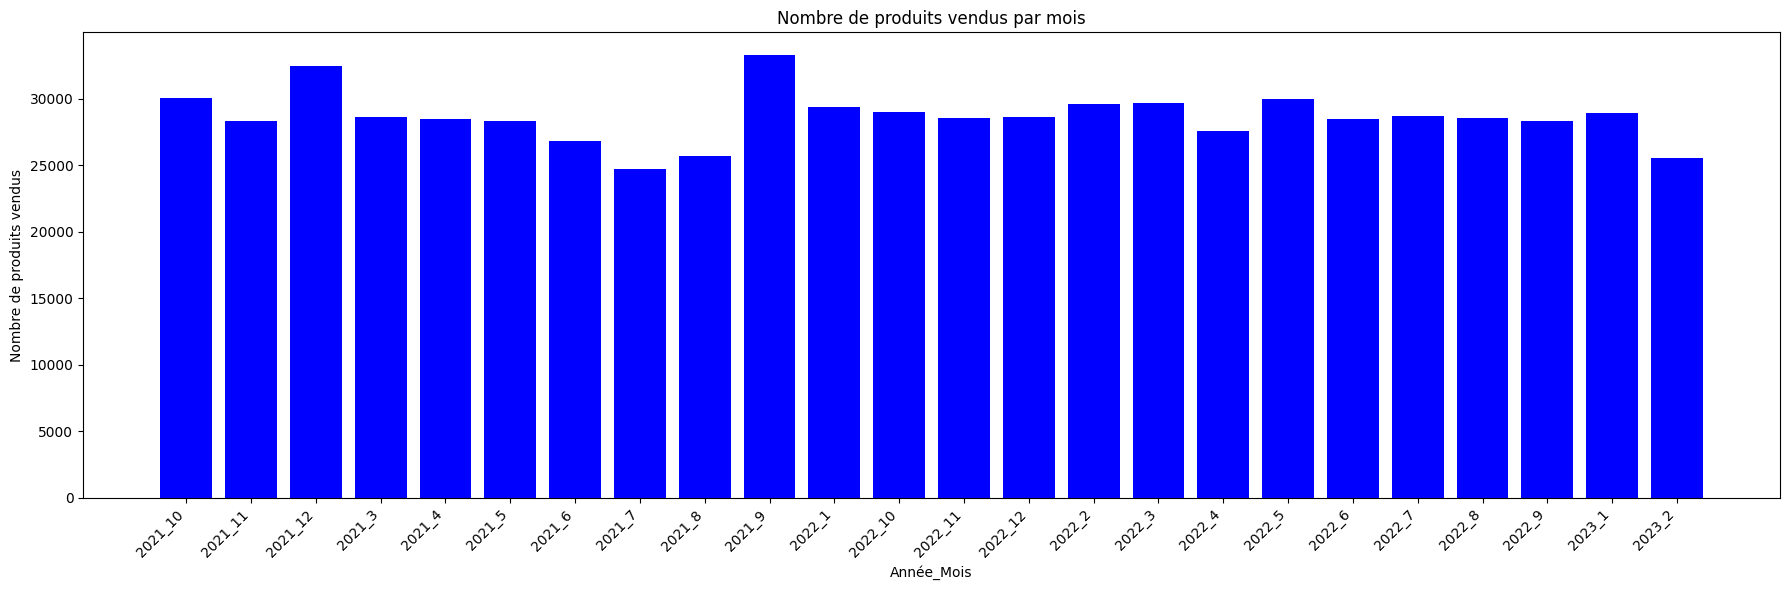

In [ ]:
plt.figure(figsize=(18, 6))
plt.bar(x=nombre_produits_vendus.index, height=nombre_produits_vendus.values, color='blue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Année_Mois')
plt.ylabel('Nombre de produits vendus')
plt.title('Nombre de produits vendus par mois')
plt.tight_layout()
plt.show()

In [ ]:
#nombre de produits par références
nombre_produits_reference = CA.groupby('id_prod').size().reset_index(name='nombre_vendus').sort_values(by='nombre_vendus',ascending=False)
print(nombre_produits_reference)

     id_prod  nombre_vendus
2591   1_369           2340
2644   1_417           2269
2641   1_414           2246
2733   1_498           2202
2653   1_425           2163
...      ...            ...
166   0_1151              1
313   0_1284              1
1784   0_541              1
3175    2_23              1
3247    2_81              1

[3265 rows x 2 columns]


In [ ]:
#repartition par catégorie
nombre_produits_categorie = CA.groupby('categ').size().reset_index(name='nombre_vendus_par_categ').sort_values(by='nombre_vendus_par_categ',ascending=False)
print(nombre_produits_categorie)

   categ  nombre_vendus_par_categ
0      0                   415459
1      1                   235592
2      2                    36483


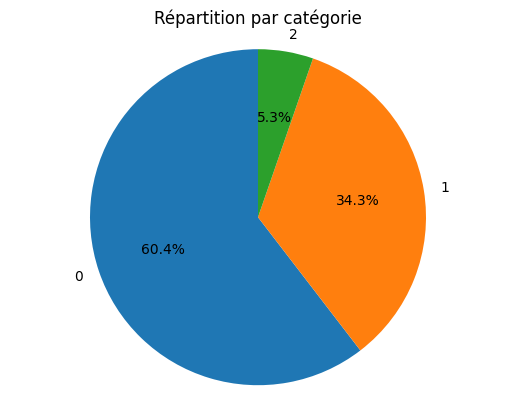

In [ ]:
import matplotlib.pyplot as plt
plt.pie(nombre_produits_categorie['nombre_vendus_par_categ'],labels=nombre_produits_categorie['categ'],autopct='%1.1f%%', startangle=90)
plt.title('Répartition par catégorie')
plt.axis('equal')
plt.show()

# Top/flop analyse



     id_prod  nombre_vendus
2591   1_369           2340
2644   1_417           2269
2641   1_414           2246
2733   1_498           2202
2653   1_425           2163
2629   1_403           2040
2640   1_413           2036
2639   1_412           2014
2632   1_406           2003
2633   1_407           2001
     id_prod  nombre_vendus
2108   0_833              1
752   0_1683              1
1792   0_549              1
2166   0_886              1
802   0_1728              1
166   0_1151              1
313   0_1284              1
1784   0_541              1
3175    2_23              1
3247    2_81              1


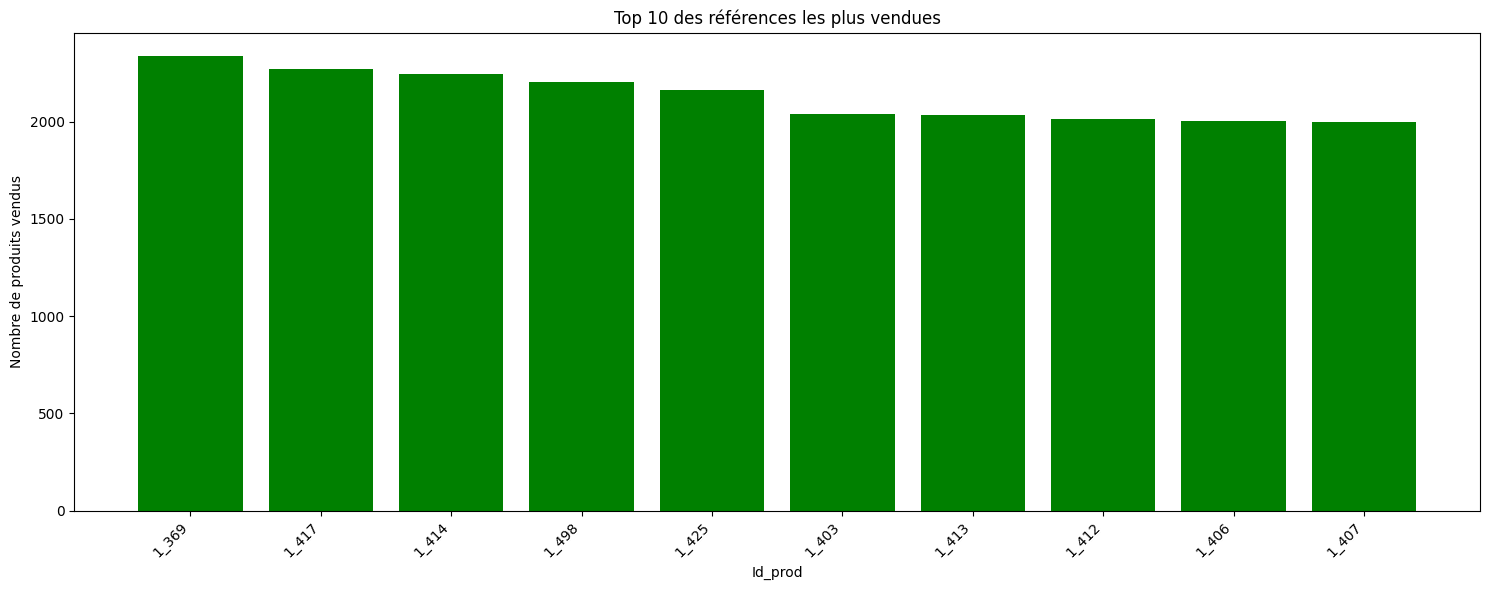

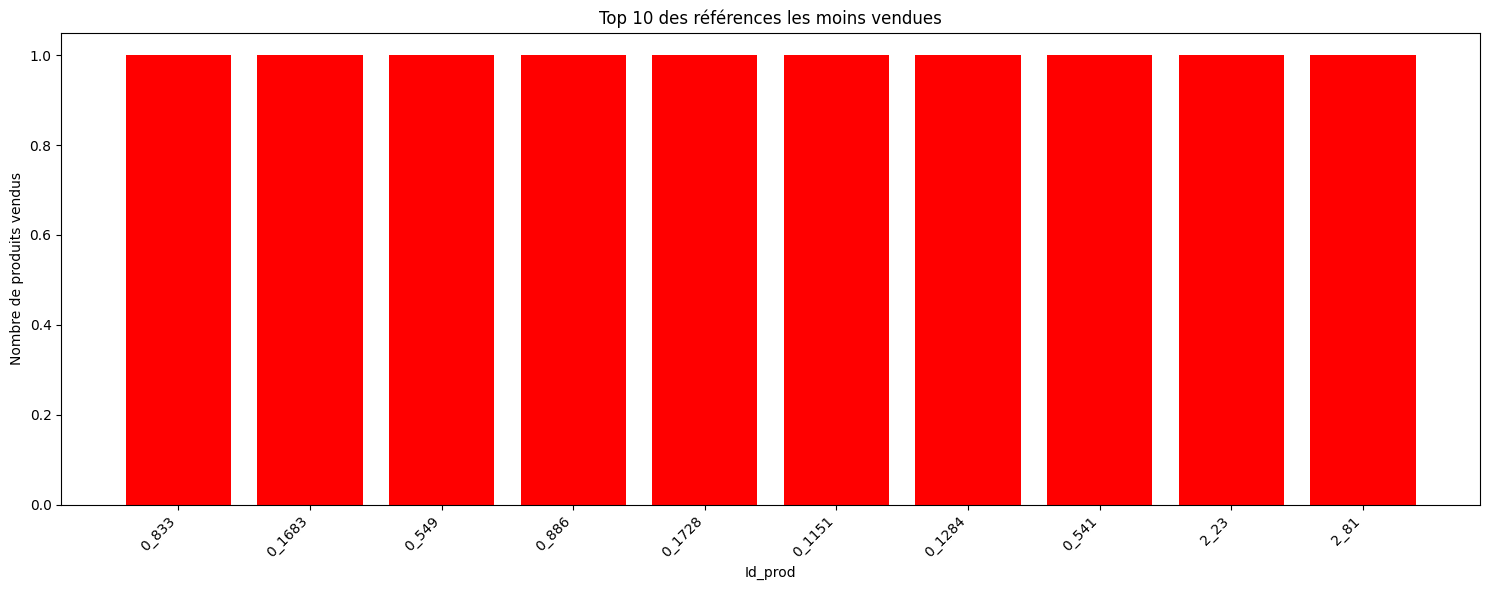

In [ ]:
#repérer les tops et flops en terme de références
CA_id_prod = CA.groupby('id_prod').size().reset_index(name='nombre_vendus')
CA_id_prod = CA_id_prod.sort_values(by='nombre_vendus',ascending=False)

#10 produits les plus vendus en termes de produits
CA_id_prod_top10=CA_id_prod.head(10)
print(CA_id_prod_top10)

#10 produits les plus moins en termes de produits
CA_id_prod_flop10=CA_id_prod.tail(10)
print(CA_id_prod_flop10)

# Graphique pour les 10 produits les plus vendus en termes de produits
plt.figure(figsize=(15, 6))
plt.bar(x=CA_id_prod_top10['id_prod'], height=CA_id_prod_top10['nombre_vendus'], color='green')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Id_prod')
plt.ylabel('Nombre de produits vendus')
plt.title('Top 10 des références les plus vendues')
plt.tight_layout()
plt.show()

# Graphique pour les 10 produits les moins vendus en termes de produits
plt.figure(figsize=(15, 6))
plt.bar(x=CA_id_prod_flop10['id_prod'], height=CA_id_prod_flop10['nombre_vendus'], color='red')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Id_prod')
plt.ylabel('Nombre de produits vendus')
plt.title('Top 10 des références les moins vendues')
plt.tight_layout()
plt.show()


     id_prod     price
3096   2_159  94893.50
3070   2_135  69334.95
3045   2_112  65407.76
3034   2_102  60736.78
3152   2_209  56971.86
2619   1_395  56617.47
2591   1_369  56136.60
3043   2_110  53846.25
2607   1_383  53834.43
2641   1_414  53522.18
     id_prod  price
925   0_1840   2.56
2179   0_898   2.54
549   0_1498   2.48
802   0_1728   2.27
1784   0_541   1.99
665   0_1601   1.99
2079   0_807   1.99
719   0_1653   1.98
313   0_1284   1.38
595   0_1539   0.99


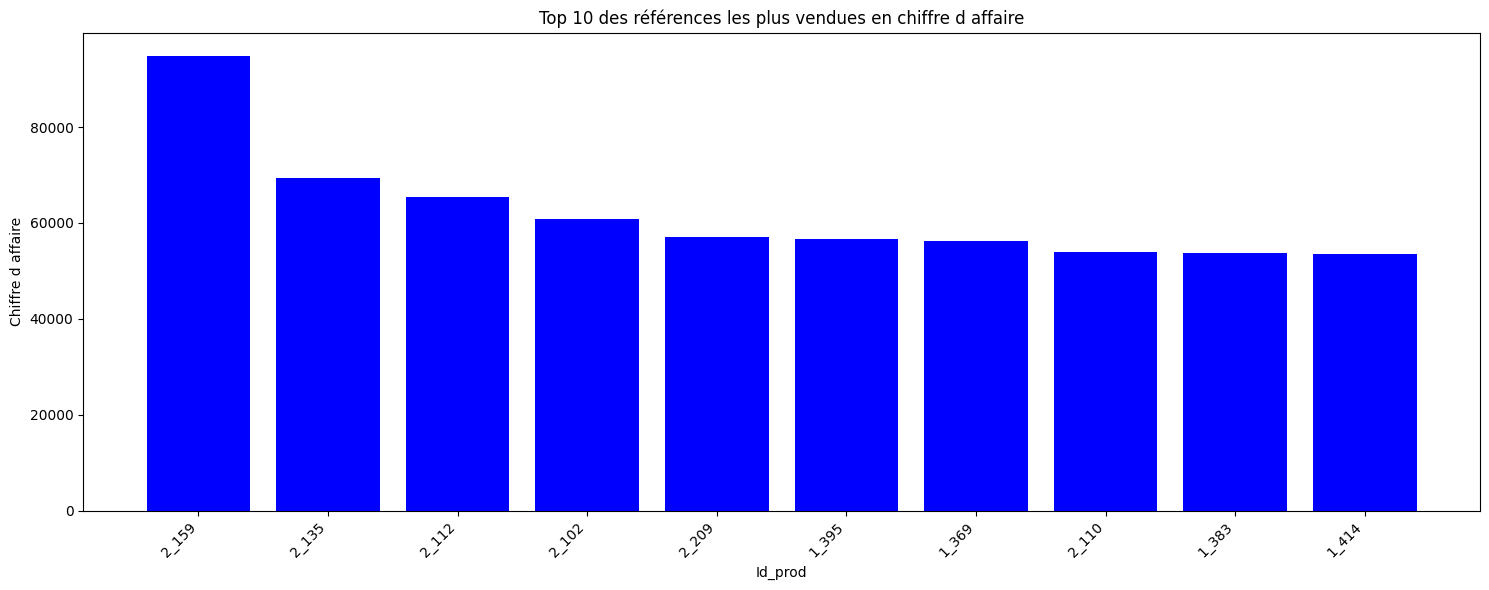

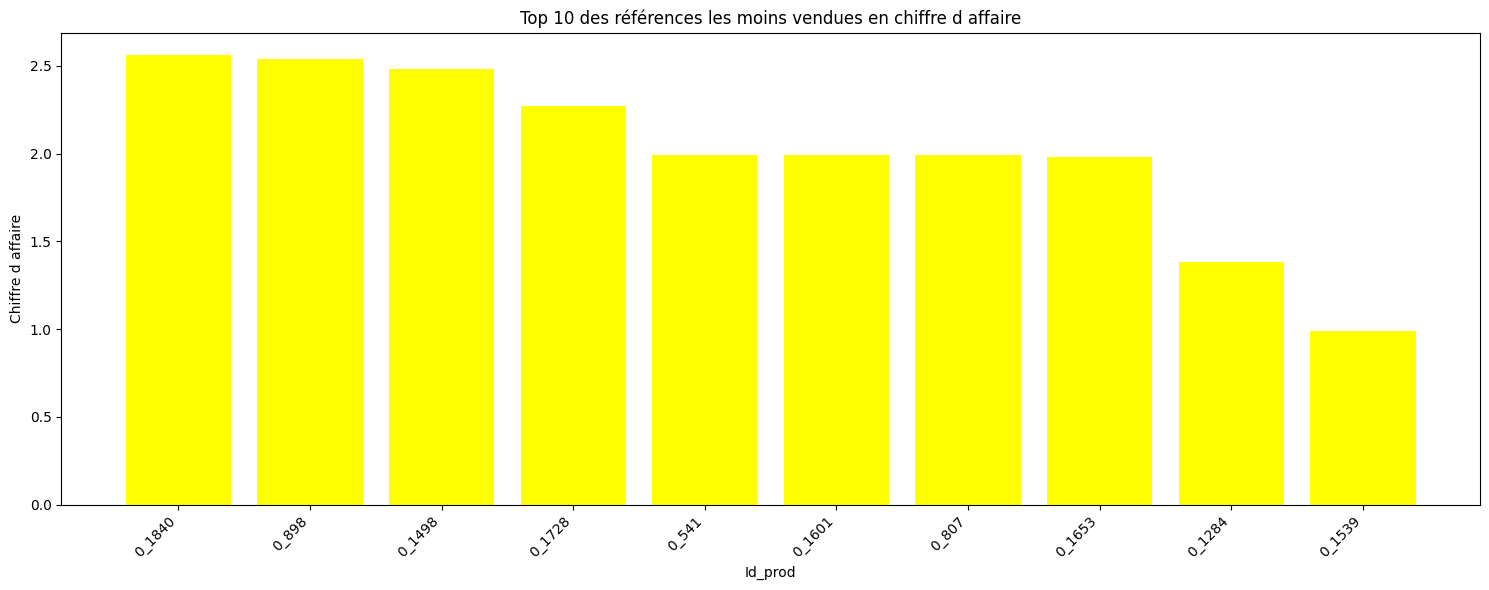

In [ ]:
#Top et flop en terme de CA
CA_id_prod_CA = CA.groupby('id_prod').agg({'price': 'sum'}).reset_index()
CA_id_prod_CA = CA_id_prod_CA.sort_values(by='price',ascending=False)
CA_top10=CA_id_prod_CA.head(10)
CA_flop10=CA_id_prod_CA.tail(10)
#10 produits les plus vendus en termes de CA
print(CA_top10)
#10 produits les plus moins en termes de CA
print(CA_flop10)

# Graphique pour les 10 produits les plus vendus en termes de CA
plt.figure(figsize=(15, 6))
plt.bar(x=CA_top10['id_prod'], height=CA_top10['price'], color='blue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Id_prod')
plt.ylabel('Chiffre d affaire')
plt.title('Top 10 des références les plus vendues en chiffre d affaire')
plt.tight_layout()
plt.show()
# Graphique pour les 10 produits les moins vendus en termes de produits
plt.figure(figsize=(15, 6))
plt.bar(x=CA_flop10['id_prod'], height=CA_flop10['price'], color='Yellow')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Id_prod')
plt.ylabel('Chiffre d affaire')
plt.title('Top 10 des références les moins vendues en chiffre d affaire')
plt.tight_layout()
plt.show()

    année_mois id_prod  nombre_vendus
0      2021_10   1_369            103
1      2021_10   1_383             95
2      2021_10   1_395             92
3      2021_10   1_414             80
4      2021_10   2_102             30
..         ...     ...            ...
235     2023_2   2_110             26
236     2023_2   2_112             51
237     2023_2   2_135             42
238     2023_2   2_159             23
239     2023_2   2_209             38

[240 rows x 3 columns]


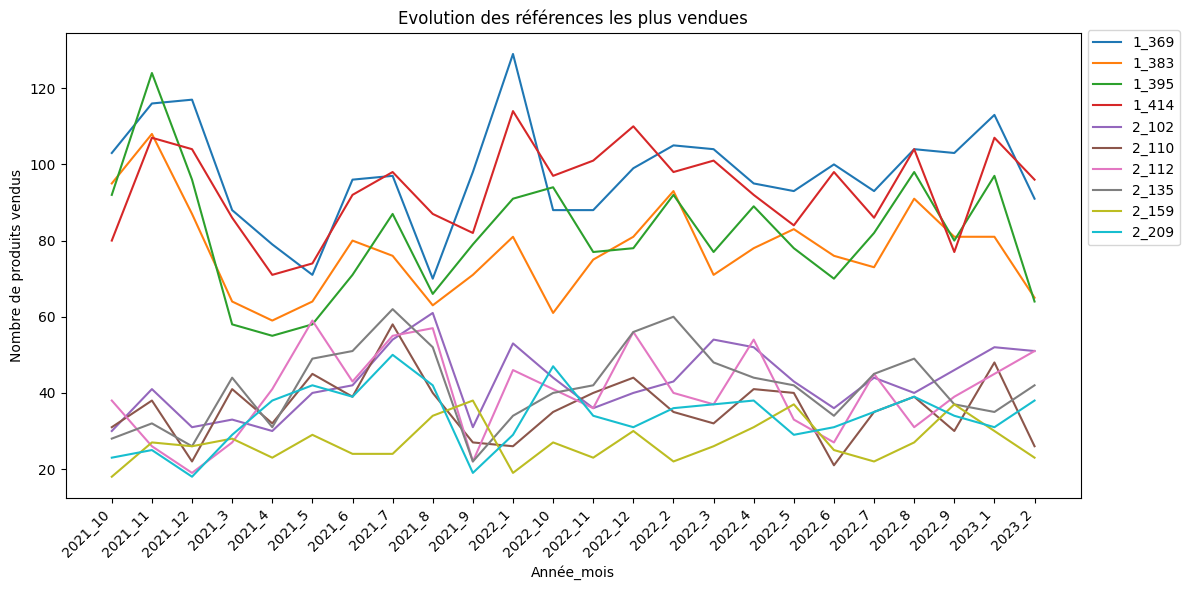

In [ ]:

#rajouter evolution dans le temps des références les plus vendus
CA_top10_evolution = CA[CA['id_prod'].isin(CA_top10['id_prod'])]
Evolution_top10 = CA_top10_evolution.groupby(['année_mois','id_prod']).size().reset_index(name='nombre_vendus')
print(Evolution_top10)

plt.figure(figsize=(12, 6))
sns.lineplot(data=Evolution_top10, x='année_mois', y='nombre_vendus', hue='id_prod')
plt.xlabel('Année_mois')
plt.ylabel('Nombre de produits vendus')
plt.title('Evolution des références les plus vendues')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1, 1.02))
plt.tight_layout()
plt.show()

In [ ]:
CA.head(10)

,id_prod,date,session_id,client_id,jour,mois,annee,année_mois,price,categ
0,0_1259,2021-03-01,s_1,c_329,1,3,2021,2021_3,11.99,0
1,0_1390,2021-03-01,s_2,c_664,1,3,2021,2021_3,19.37,0
2,0_1352,2021-03-01,s_3,c_580,1,3,2021,2021_3,4.50,0
3,0_1458,2021-03-01,s_4,c_7912,1,3,2021,2021_3,6.55,0
4,0_1358,2021-03-01,s_5,c_2033,1,3,2021,2021_3,16.49,0
5,0_1073,2021-03-01,s_6,c_4908,1,3,2021,2021_3,13.99,0
6,0_1304,2021-03-01,s_7,c_1609,1,3,2021,2021_3,5.86,0
7,0_279,2021-03-01,s_6,c_4908,1,3,2021,2021_3,16.99,0
8,1_445,2021-03-01,s_8,c_7991,1,3,2021,2021_3,23.99,1
9,1_556,2021-03-01,s_9,c_6171,1,3,2021,2021_3,24.47,1


   categ  nombre_vendus_par_categ
0      0                   415459
1      1                   235592
2      2                    36483


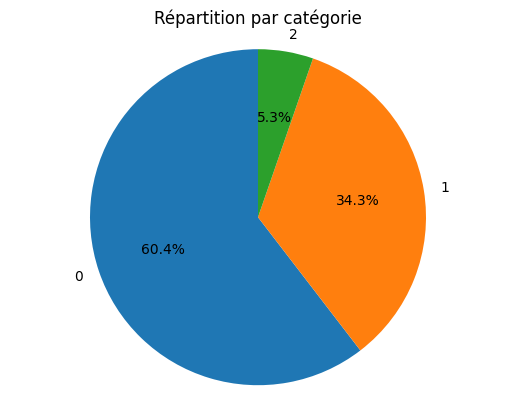

In [ ]:
#Répartition en terme de categorie sur les produits vendus
CA_categ = CA.groupby('categ').size().reset_index(name='nombre_vendus_par_categ').sort_values(by='nombre_vendus_par_categ',ascending=False)
print(CA_categ)
plt.pie(CA_categ['nombre_vendus_par_categ'],labels=CA_categ['categ'],autopct='%1.1f%%', startangle=90)
plt.title('Répartition par catégorie')
plt.axis('equal')
plt.show()

In [ ]:
#Repartition du chiffre des client BtoB
CA_client_top = CA.groupby('client_id').agg({'price': 'sum'}).reset_index()
CA_client_top = CA_client_top.sort_values(by='price',ascending=False)
print(CA_client_top.head(10))

     client_id      price
677     c_1609  326039.89
4388    c_4958  290227.03
6337    c_6714  153918.60
2724    c_3454  114110.57
634     c_1570    5285.82
2513    c_3263    5276.87
1268    c_2140    5260.18
2108    c_2899    5214.05
7006    c_7319    5155.77
7715    c_7959    5135.75


In [ ]:
#Distinction des clients BtoB
CA_TOP4 = CA_client_top.head(4)
print(CA_TOP4)

     client_id      price
677     c_1609  326039.89
4388    c_4958  290227.03
6337    c_6714  153918.60
2724    c_3454  114110.57


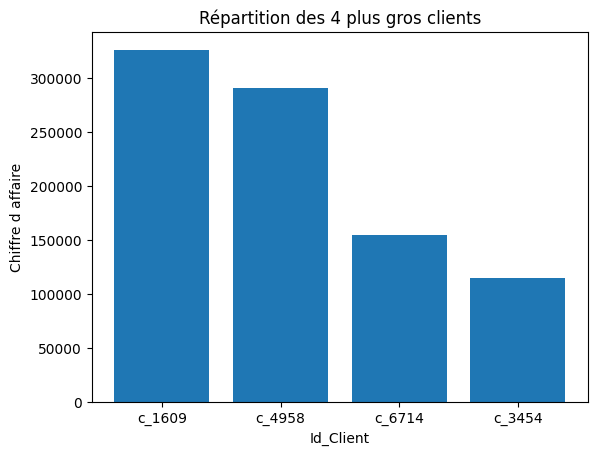

In [ ]:
#Répartition des 4 plus gros clients
plt.bar(height=CA_TOP4['price'], x=CA_TOP4['client_id'],)
plt.xlabel('Id_Client')
plt.ylabel('Chiffre d affaire')
plt.title('Répartition des 4 plus gros clients')
plt.show()

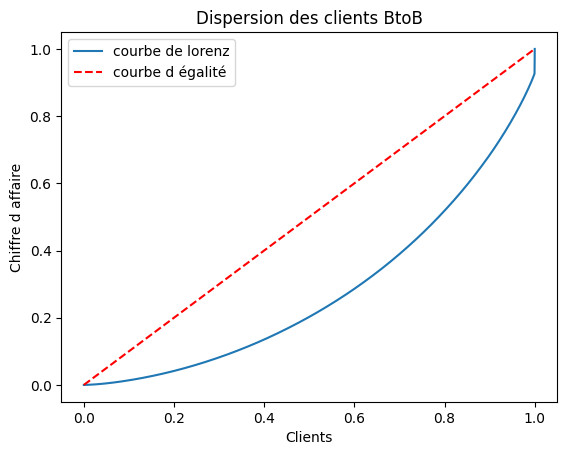

In [ ]:
#courbe de lorenz sur les clients BtoB
CA_client_top = CA_client_top.sort_values(by='price')
CA_client_top['cumsum'] = CA_client_top['price'].cumsum()
lorenz = CA_client_top['cumsum'] / CA_client_top['price'].sum()

# ajout des points de départs du graphique
lorenz = np.append([0], lorenz)

# creation de l'axe x du graphique de lorenz
x = np.arange(len(lorenz)) / (len(lorenz) - 1)

# Plot the Lorenz curve
plt.plot(x, lorenz, label='courbe de lorenz')
plt.plot([0, 1], [0, 1], 'r--', label='courbe d égalité')
plt.legend(bbox_to_anchor=(5, 5))
plt.xlabel('Clients')
plt.ylabel('Chiffre d affaire')
plt.title('Dispersion des clients BtoB')
plt.legend()
plt.show()

## 4 Analyse des corrélations


In [ ]:
#Ajout colonne age dans le dataframe complet
from datetime import datetime

def calculer_age(annee):
    today = datetime.today()
    age = today.year - annee
    return age

customers['age'] = [calculer_age(x) for x in customers['birth']]

# les bornes d'âge pour les tranches // revoir les intervalles
bins = [20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = [ '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90 +']

# Ajout une nouvelle colonne 'groupe_age' avec les tranches d'âge
customers['groupe_age'] = pd.cut(customers['age'], bins=bins, labels=labels, right=False)
customers.describe(include='all')

,client_id,sex,birth,age,groupe_age
count,8621,8621,8621.000000,8621.000000,8621
unique,8621,2,NaN,NaN,8
top,c_84,f,NaN,NaN,40-49
freq,1,4490,NaN,NaN,1730
mean,NaN,NaN,1978.275606,46.724394,NaN
std,NaN,NaN,16.917958,16.917958,NaN
min,NaN,NaN,1929.000000,21.000000,NaN
25%,NaN,NaN,1966.000000,33.000000,NaN
50%,NaN,NaN,1979.000000,46.000000,NaN
75%,NaN,NaN,1992.000000,59.000000,NaN


In [ ]:
#Création de la jointure entre le dataframe CA et customers (clients)
Df_complet = pd.merge(CA,customers,on='client_id')
print(Df_complet.head())

  id_prod        date session_id client_id  jour  mois  annee année_mois  \
0  0_1259  2021-03-01        s_1     c_329     1     3   2021     2021_3   
1  0_1390  2021-03-01        s_2     c_664     1     3   2021     2021_3   
2  0_1352  2021-03-01        s_3     c_580     1     3   2021     2021_3   
3  0_1458  2021-03-01        s_4    c_7912     1     3   2021     2021_3   
4  0_1358  2021-03-01        s_5    c_2033     1     3   2021     2021_3   

   price  categ sex  birth  age groupe_age  
0  11.99      0   f   1967   58      50-59  
1  19.37      0   m   1960   65      60-69  
2   4.50      0   m   1988   37      30-39  
3   6.55      0   f   1989   36      30-39  
4  16.49      0   f   1956   69      60-69  


In [ ]:
#envlever les client BtoB du df pour analyser
df_sans_BtoB = Df_complet.mask(Df_complet['client_id'].isin(CA_TOP4['client_id']))
Control_df_sans_BtoB = df_sans_BtoB.groupby('client_id').agg({'price': 'sum'}).reset_index()
Control_df_sans_BtoB = Control_df_sans_BtoB.rename(columns={'price': 'nombre_vendus'})
Control_df_sans_BtoB = Control_df_sans_BtoB.sort_values(by='nombre_vendus',ascending=False)
print(Control_df_sans_BtoB.head(10))

     client_id  nombre_vendus
634     c_1570        5285.82
2512    c_3263        5276.87
1267    c_2140        5260.18
2107    c_2899        5214.05
7002    c_7319        5155.77
7711    c_7959        5135.75
470     c_1422        5131.36
7116    c_7421        5097.18
7787    c_8026        5082.58
1672    c_2505        5059.35


sex         f       m
categ                
0.0    200793  186488
1.0    115721  104884
2.0     16980   15868


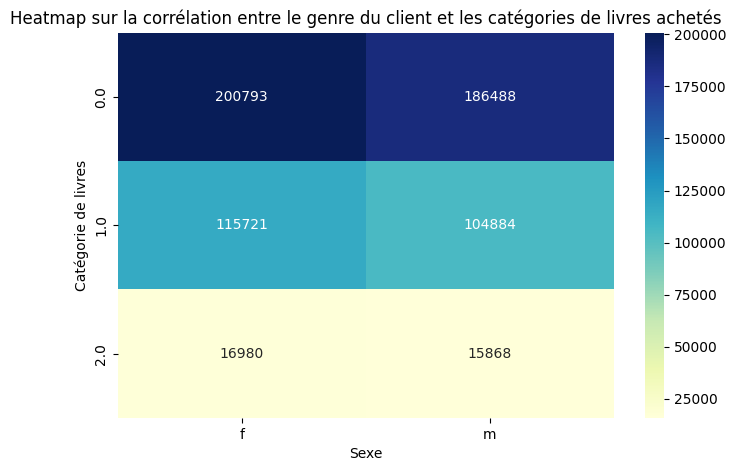

In [ ]:
#Corrélation du genre du client et catégorie de produits achetés (livres)
corr_genre_categ = pd.crosstab(df_sans_BtoB['categ'],df_sans_BtoB['sex'])
print(corr_genre_categ)
#Heatmap de la corrélation
plt.figure(figsize=(8,5))
sns.heatmap(corr_genre_categ, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Heatmap sur la corrélation entre le genre du client et les catégories de livres achetés")
plt.ylabel("Catégorie de livres")
plt.xlabel("Sexe")
plt.show()

In [ ]:
# Test du chi² d’indépendance
chi2, p, dof, expected = chi2_contingency(corr_genre_categ)
print("Chi2:", chi2)
print(f"P-valeur : {p:.4f}")
print("Degré de liberté:", dof)
print("Fréquence attendues:\n", expected)
#Interprétation
if p < 0.05:
    print("\n👉 Il existe une dépendance significative entre le sexe et la catégorie de livres achetés.")
else:
    print("\n👉 Pas de corrélation significative entre le sexe et la catégorie de livres achetés.")

Chi2: 22.66856665178056
P-valeur : 0.0000
Degré de liberté: 2
Fréquence attendues:
 [[201574.89662481 185706.10337519]
 [114822.13191434 105782.86808566]
 [ 17096.97146086  15751.02853914]]

👉 Il existe une dépendance significative entre le sexe et la catégorie de livres achetés.


In [ ]:
# Corrélation de l'age des clients et montant totale des achats (deux variables quantitatives)
corr_age_montant = df_sans_BtoB.groupby('age')['price'].sum().reset_index()
print(corr_age_montant)

     age      price
0   21.0  616418.15
1   22.0  180680.89
2   23.0  186791.83
3   24.0  181233.57
4   25.0  167388.08
..   ...        ...
71  92.0    5477.83
72  93.0    5059.18
73  94.0    2815.45
74  95.0    4251.22
75  96.0    3249.84

[76 rows x 2 columns]


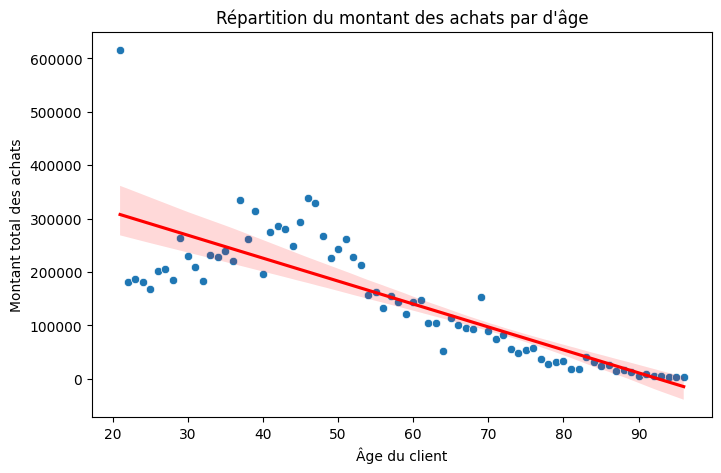

Corrélation de Pearson : r = -0.83, p-value = 0.00
👉 Il existe une corrélation significative entre l'âge et le montant des achats.


In [ ]:
from scipy.stats import f_oneway
from scipy.stats import pearsonr # Import pearsonr

#Nuage de point
plt.figure(figsize=(8,5))
sns.scatterplot(data=corr_age_montant, x='age', y='price')
sns.regplot(data=corr_age_montant, x='age', y='price', scatter=False, color="red")
plt.xlabel("Âge du client")
plt.ylabel("Montant total des achats")
plt.title("Répartition du montant des achats par d'âge")
plt.show()

# Test de corrélation de Pearson
corr, pval = pearsonr(corr_age_montant['age'], corr_age_montant['price'])
print(f"Corrélation de Pearson : r = {corr:.2f}, p-value = {pval:.2f}")

if pval < 0.05:
    print("👉 Il existe une corrélation significative entre l'âge et le montant des achats.")
else:
    print("👉 Pas de corrélation significative entre l'âge et le montant des achats.")

In [ ]:
#corrélation age client et fréquence d'achat (deux variables quantitatives)
corr_age_fréquence = df_sans_BtoB.groupby('age')['session_id'].count().reset_index()
print(corr_age_fréquence)

     age  session_id
0   21.0       15497
1   22.0        4491
2   23.0        4711
3   24.0        4378
4   25.0        4529
..   ...         ...
71  92.0         336
72  93.0         312
73  94.0         170
74  95.0         238
75  96.0         202

[76 rows x 2 columns]


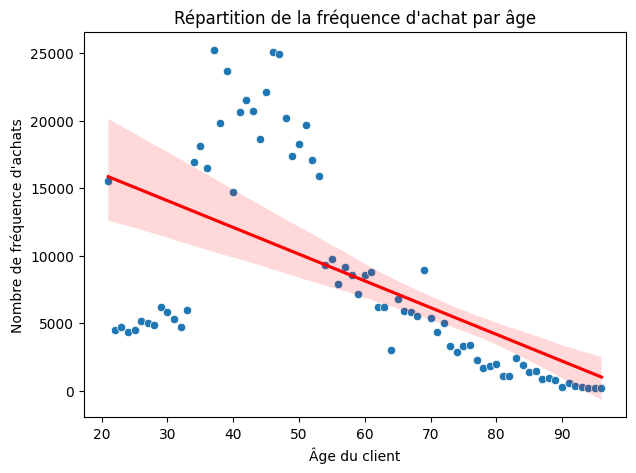

In [ ]:
#Nuage de points
plt.figure(figsize=(7,5))
sns.scatterplot(data=corr_age_fréquence, x='age', y='session_id')
sns.regplot(data=corr_age_fréquence, x='age', y='session_id', scatter=False, color="red")
plt.xlabel("Âge du client")
plt.ylabel("Nombre de fréquence d'achats")
plt.title("Répartition de la fréquence d'achat par âge")
plt.show()


In [ ]:
# Tests de statistiques
pearson_corr, pearson_p = pearsonr(corr_age_fréquence['age'], corr_age_fréquence['session_id'])

print(f"Corrélation de Pearson : r = {pearson_corr:.2f}, p = {pearson_p:.4f}")

# Interprétation
if pearson_p < 0.05:
    print("👉 Il existe une corrélation linéaire significative entre l'âge et la fréquence d'achat (Pearson).")
else:
    print("👉 Pas de corrélation linéaire significative (Pearson).")


Corrélation de Pearson : r = -0.58, p = 0.0000
👉 Il existe une corrélation linéaire significative entre l'âge et la fréquence d'achat (Pearson).


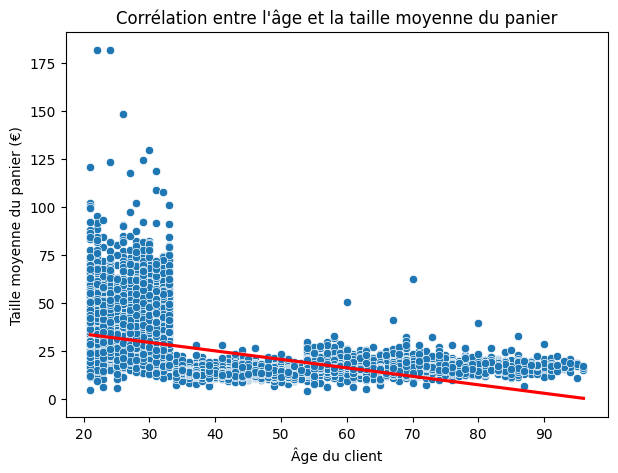

Corrélation de Pearson : r = -0.51, p = 0.0000
Corrélation de Spearman : rho = -0.33, p = 0.0000
👉 Il existe une corrélation linéaire significative entre l'âge et la taille moyenne du panier (Pearson).
👉 Il existe une corrélation monotone significative entre l'âge et la taille moyenne du panier (Spearman).


In [ ]:
#Corélation entre l'age des clients et de la taille du panier moyen (deux variables quantitatives)

from scipy.stats import pearsonr, spearmanr

#Calcul de la taille moyenne du panier par client
panier_moyen = df_sans_BtoB.groupby('client_id').agg({
    'age': 'first',
    'price': 'mean'
}).reset_index().rename(columns={'price': 'panier_moyen'})

#Nuage de points avec droite de tendance
plt.figure(figsize=(7,5))
sns.scatterplot(data=panier_moyen, x='age', y='panier_moyen')
sns.regplot(data=panier_moyen, x='age', y='panier_moyen', scatter=False, color="red")
plt.xlabel("Âge du client")
plt.ylabel("Taille moyenne du panier (€)")
plt.title("Corrélation entre l'âge et la taille moyenne du panier")
plt.show()

# Tests de statistiques
pearson_corr, pearson_p = pearsonr(panier_moyen['age'], panier_moyen['panier_moyen'])
spearman_corr, spearman_p = spearmanr(panier_moyen['age'], panier_moyen['panier_moyen'])

print(f"Corrélation de Pearson : r = {pearson_corr:.2f}, p = {pearson_p:.4f}")
print(f"Corrélation de Spearman : rho = {spearman_corr:.2f}, p = {spearman_p:.4f}")

# Interprétation
if pearson_p < 0.05:
    print("👉 Il existe une corrélation linéaire significative entre l'âge et la taille moyenne du panier (Pearson).")
else:
    print("👉 Pas de corrélation linéaire significative (Pearson).")

if spearman_p < 0.05:
    print("👉 Il existe une corrélation monotone significative entre l'âge et la taille moyenne du panier (Spearman).")
else:
    print("👉 Pas de corrélation monotone significative (Spearman).")

categ          0.0    1.0    2.0
groupe_age                      
20-29        12032  21380  21391
30-39        95870  37209   8952
40-49       154841  50421    733
50-59        75247  46735    736
60-69        28164  36955    602
70-79        14359  18808    272
80-89         5872   7915    146
90 +           896   1182     16


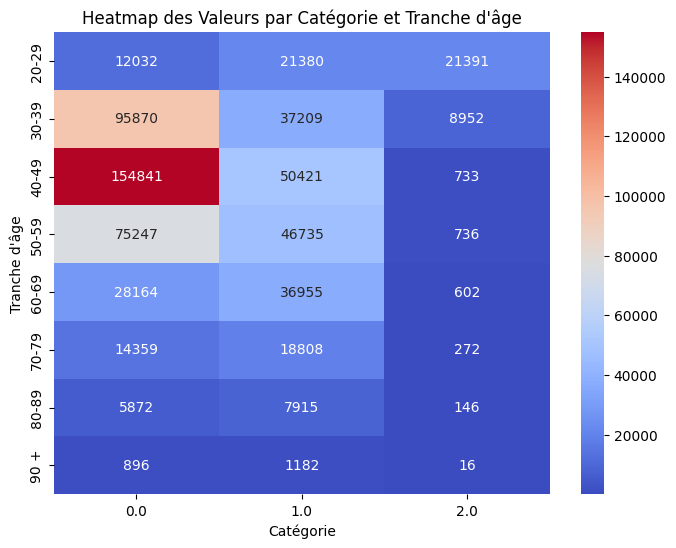

In [ ]:
# tableau de contingence pour deux variables qualitatives
corr_groupe_age_categ = pd.crosstab(index=df_sans_BtoB['groupe_age'], columns=df_sans_BtoB['categ'])
print(corr_groupe_age_categ)

# Créez la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_groupe_age_categ, annot=True, cmap='coolwarm', fmt='d')

# Personnalisez les axes et le titre
plt.xlabel('Catégorie')
plt.ylabel("Tranche d'âge")
plt.title("Heatmap des Valeurs par Catégorie et Tranche d'âge")

# Affichez la heatmap
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

# Calculer le test du chi2
chi2_statistic, p_value, dof, expected_freq = chi2_contingency(corr_groupe_age_categ)

# Afficher les résultats
print(f"Statistique du chi2 : {chi2_statistic:.4f}")
print(f"P-valeur : {p_value:.4f}")

# Interprétation
if p_value < 0.05:
    print("\n👉 Il existe une dépendance significative entre les tranches d'âge et les catégories de produits achetés.")
else:
    print("\n👉 Pas de dépendance significative entre les tranches d'âge et les catégories de produits achetés.")

Statistique du chi2 : 194834.0168
P-valeur : 0.0000

👉 Il existe une dépendance significative entre les tranches d'âge et les catégories de produits achetés.
